<a href="https://colab.research.google.com/github/Abel-Jacob/Mini-project-/blob/main/sneaker_auth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

import matplotlib.pyplot as plt


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/sneaker_dataset"

BRAND_TRAIN = os.path.join(BASE_PATH, "brand_classifier", "train")
BRAND_VALID = os.path.join(BASE_PATH, "brand_classifier", "valid")
BRAND_TEST  = os.path.join(BASE_PATH, "brand_classifier", "test")

AUTH_TRAIN = os.path.join(BASE_PATH, "auth_dataset", "train")
AUTH_VALID = os.path.join(BASE_PATH, "auth_dataset", "valid")
AUTH_TEST  = os.path.join(BASE_PATH, "auth_dataset", "test")

print("Brand train path:", BRAND_TRAIN)
print("Auth train path:", AUTH_TRAIN)


Brand train path: /content/drive/MyDrive/sneaker_dataset/brand_classifier/train
Auth train path: /content/drive/MyDrive/sneaker_dataset/auth_dataset/train


In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

valid_gen = ImageDataGenerator(rescale=1./255)

test_gen = ImageDataGenerator(rescale=1./255)


In [ ]:
brand_train = train_gen.flow_from_directory(
    BRAND_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

brand_valid = valid_gen.flow_from_directory(
    BRAND_VALID,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

brand_test = test_gen.flow_from_directory(
    BRAND_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

brand_classes = list(brand_train.class_indices.keys())

print("Brand classes:", brand_classes)


Found 2193 images belonging to 2 classes.
Found 761 images belonging to 2 classes.
Found 764 images belonging to 2 classes.
Brand classes: ['adidas', 'nike']


In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

brand_output = Dense(len(brand_classes), activation="softmax")(x)

brand_model = Model(inputs=base_model.input, outputs=brand_output)

brand_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

brand_model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
brand_history = brand_model.fit(
    brand_train,
    validation_data=brand_valid,
    epochs=10
)


Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.7654 - loss: 0.5258 - val_accuracy: 0.9133 - val_loss: 0.2018
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 51s 734ms/step - accuracy: 0.8529 - loss: 0.3224 - val_accuracy: 0.9593 - val_loss: 0.1569
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 52s 753ms/step - accuracy: 0.9164 - loss: 0.2468 - val_accuracy: 0.9711 - val_loss: 0.1306
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 51s 747ms/step - accuracy: 0.9420 - loss: 0.1772 - val_accuracy: 0.9593 - val_loss: 0.1304
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 51s 736ms/step - accuracy: 0.9468 - loss: 0.1596 - val_accuracy: 0.9658 - val_loss: 0.1147
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 50s 721ms/step - accuracy: 0.9473 - loss: 0.1441 - val_accuracy: 0.9711 - val_loss: 0.0997
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 51s 732ms/step - accuracy: 0.9653 - loss: 0.1210 - val_accuracy: 0.9750 - val_loss: 0.0957
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 51s 745ms/step - accuracy: 0.9630 - loss: 0.1085 - val_accura

In [ ]:
brand_model.save("/content/drive/MyDrive/brand_model.h5")

print("Brand model saved.")


Brand model saved.


In [ ]:
auth_train = train_gen.flow_from_directory(
    AUTH_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

auth_valid = valid_gen.flow_from_directory(
    AUTH_VALID,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

auth_test = test_gen.flow_from_directory(
    AUTH_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

auth_classes = list(auth_train.class_indices.keys())

print("Authenticity classes:", auth_classes)


Found 3177 images belonging to 2 classes.
Found 870 images belonging to 2 classes.
Found 481 images belonging to 2 classes.
Authenticity classes: ['genuine', 'non_genuine']


In [ ]:
base_model2 = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model2.trainable = False

x2 = GlobalAveragePooling2D()(base_model2.output)
x2 = Dense(128, activation="relu")(x2)
x2 = Dropout(0.5)(x2)

auth_output = Dense(len(auth_classes), activation="softmax")(x2)

auth_model = Model(inputs=base_model2.input, outputs=auth_output)

auth_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

auth_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
auth_history = auth_model.fit(
    auth_train,
    validation_data=auth_valid,
    epochs=10
)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1463s 15s/step - accuracy: 0.5655 - loss: 0.8053 - val_accuracy: 0.6793 - val_loss: 0.6013
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 549ms/step - accuracy: 0.6665 - loss: 0.6181 - val_accuracy: 0.7149 - val_loss: 0.5633
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 547ms/step - accuracy: 0.6828 - loss: 0.5871 - val_accuracy: 0.7391 - val_loss: 0.5376
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 546ms/step - accuracy: 0.7279 - loss: 0.5342 - val_accuracy: 0.7356 - val_loss: 0.5299
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 550ms/step - accuracy: 0.7498 - loss: 0.5189 - val_accuracy: 0.7506 - val_loss: 0.5104
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 550ms/step - accuracy: 0.7436 - loss: 0.5076 - val_accuracy: 0.7506 - val_loss: 0.5036
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 557ms/step - accuracy: 0.7639 - loss: 0.4805 - val_accuracy: 0.7494 - val_loss: 0.5017
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 553ms/step - accuracy: 0.7747 - loss: 0

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(brand_history.history['accuracy'])
plt.plot(brand_history.history['val_accuracy'])
plt.title("Brand Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(brand_history.history['loss'])
plt.plot(brand_history.history['val_loss'])
plt.title("Brand Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
auth_model.save("/content/drive/MyDrive/auth_model.h5")

print("Authenticity model saved.")


Authenticity model saved.


In [ ]:
brand_model = load_model("/content/drive/MyDrive/brand_model.h5")
auth_model = load_model("/content/drive/MyDrive/auth_model.h5")

def predict_shoe(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    brand_pred = brand_model.predict(img_array)
    auth_pred = auth_model.predict(img_array)

    brand = brand_classes[np.argmax(brand_pred)]
    auth = auth_classes[np.argmax(auth_pred)]

    brand_conf = np.max(brand_pred) * 100
    auth_conf = np.max(auth_pred) * 100

    print("\nRESULT")
    print("------------------")
    print(f"Brand: {brand} ({brand_conf:.2f}%)")
    print(f"Authenticity: {auth} ({auth_conf:.2f}%)")


In [ ]:
from google.colab import files
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

def upload_and_analyze():

    # Open file picker
    uploaded = files.upload()

    # Get selected file
    img_path = list(uploaded.keys())[0]

    print("\nAnalyzing:", img_path)

    # Load image
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Brand prediction
    brand_pred = brand_model.predict(img_array)
    brand_index = np.argmax(brand_pred[0])
    brand_name = brand_classes[brand_index]
    brand_conf = brand_pred[0][brand_index] * 100

    # Authenticity prediction
    auth_pred = auth_model.predict(img_array)
    auth_index = np.argmax(auth_pred[0])
    auth_name = auth_classes[auth_index]
    auth_conf = auth_pred[0][auth_index] * 100

    # Print results
    print("\nRESULT")
    print("----------------------")
    print(f"Brand: {brand_name} ({brand_conf:.2f}%)")
    print(f"Authenticity: {auth_name} ({auth_conf:.2f}%)")

    # GradCAM
    last_conv_layer = brand_model.get_layer("Conv_1")

    grad_model = Model(
        inputs=brand_model.inputs,
        outputs=[last_conv_layer.output, brand_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, brand_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # Overlay heatmap
    img_cv = cv2.imread(img_path)
    img_cv = cv2.resize(img_cv, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + img_cv

    # Show results visually
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(superimposed.astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.title("GradCAM Heatmap")
    plt.axis("off")

    plt.show()


Saving Air-Jordan-1-Mid-Chicago-2020-GS.png to Air-Jordan-1-Mid-Chicago-2020-GS (2).png

Analyzing: Air-Jordan-1-Mid-Chicago-2020-GS (2).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

RESULT
----------------------
Brand: nike (59.30%)
Authenticity: genuine (93.72%)


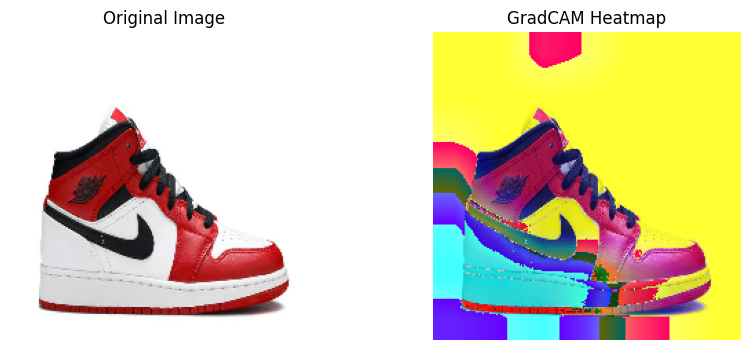

In [ ]:
upload_and_analyze()

